In [1]:
import gymnasium as gym
import numpy as np
import copy

from stable_baselines3 import DDPG
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from stable_baselines3.common.noise import (
    NormalActionNoise,
    OrnsteinUhlenbeckActionNoise,
)
from src.env import RFQEnvironment
from src.eval import evaluate_pricing_agent, visualize_simulation

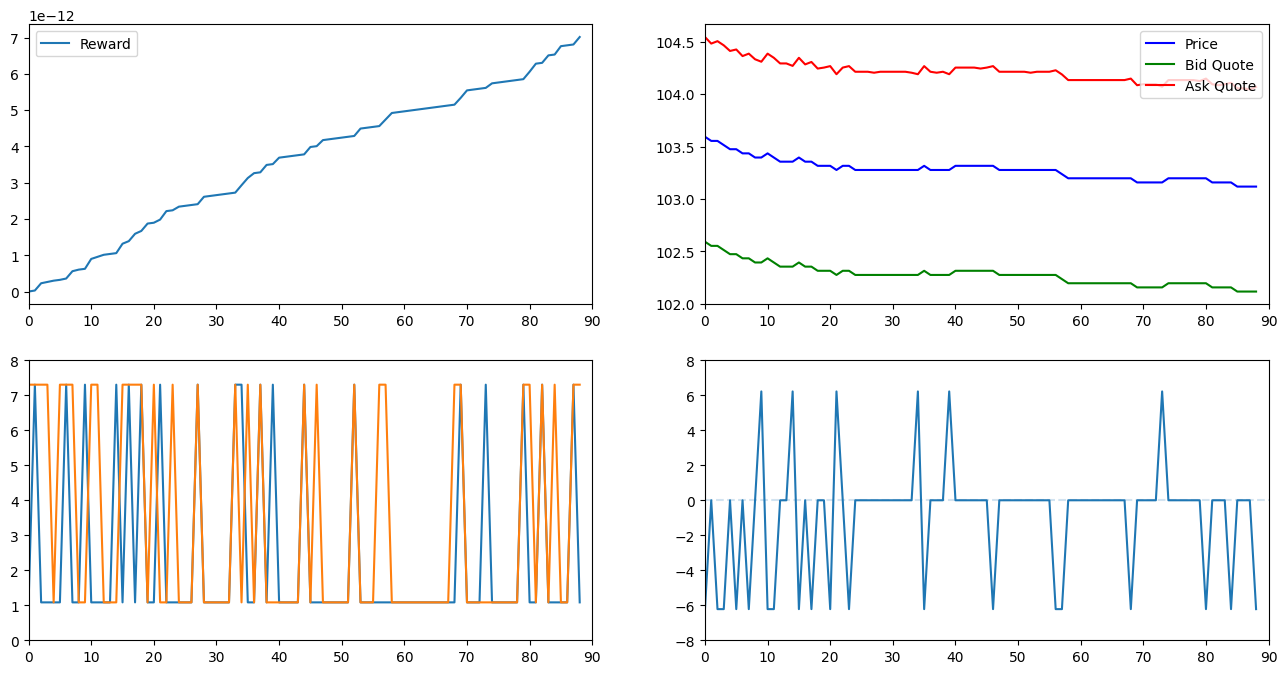

In [2]:
class TrainingCallback(BaseCallback):
    def __init__(self, performance_checkpoint_freq, env):
        self.n_calls = 0
        self.performance_checkpoint_freq = performance_checkpoint_freq
        self.env = env

    def _on_step(self):
        if self.num_timesteps % self.performance_checkpoint_freq == 0:
            evaluate_pricing_agent(self.env, self.model, 500)
        return True


env = RFQEnvironment(
    np.array([10.83, 73.03]) / 10,
    np.array(
        [
            [-14.01, 4.37, 4.37, 5.27],
            [19.32, -60.91, 12.54, 29.05],
            [19.32, 12.54, -60.91, 29.05],
            [23.67, 15.00, 15.00, -53.67],
        ]
    ),
    σ=0,
    reward_setting="value",
)


training_callback = TrainingCallback(1000, copy.deepcopy(env))
checkpoint_callback = CheckpointCallback(1000, "models", name_prefix="DDPG")


# The noise objects for DDPG
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(
    mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions)
)

model = DDPG(
    "MlpPolicy", env, action_noise=action_noise, verbose=1, tensorboard_log="results"
)

In [3]:
model.learn(
    total_timesteps=100000,
    callback=[training_callback, checkpoint_callback],
)

Logging to results\DDPG_42
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 89       |
|    ep_rew_mean     | -432     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 74       |
|    time_elapsed    | 4        |
|    total_timesteps | 356      |
| train/             |          |
|    actor_loss      | 11.7     |
|    critic_loss     | 5.13     |
|    learning_rate   | 0.001    |
|    n_updates       | 255      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 89       |
|    ep_rew_mean     | -501     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 64       |
|    time_elapsed    | 11       |
|    total_timesteps | 712      |
| train/             |          |
|    actor_loss      | 22.1     |
|    critic_loss     | 19.2     |
|    learning_rate   | 0.001    |
|    n_updates       

In [ ]:
visualize_simulation(env, model)